### **Imports and other prerequisites**

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from nelson_siegel_svensson.calibrate import calibrate_nss_ols
from scipy.interpolate import Rbf
from BnS import BnS
from Sampling import Sampling

### **Initial configuration**

Linking data files and setting up some config parameters

In [2]:
CSV_PATH = "Data/gld_chain_wide_chain.csv"
META_JSON_PATH = "Data/gld_chain_wide_meta.json" 
OUTPUT_IV_PATH = "Data/gld_chain_with_iv_essential.csv"

DIVIDEND_YIELD = 0.0 # Assuming q=0 for GLD (Gold ETF)
MIN_PRICE = 1.0      # Remove options cheaper than 1$ to avoid bid/ask noise

# === FILTERS (MONEYNESS & TIME) ===
MONEYNESS_WINDOW = 0.20 # Focus on +/- 20% around the Spot price
                        # Ignore deep Out/In The Money options to avoid IV spikes

T_MIN = 60.0 / 365.0 # Ignore options expiring in less than 60 days (avoid short-term noise)
MIN_POINTS_PER_EXPIRY = 5 # Minimum valid options required per expiration date

# === Black-Scholes Bisection Parameters for Implied Volatility Calculation ===
# (Override these values as needed to experiment with different convergence settings)
MIN_VOL = 1e-4      # Lower bound for volatility search
MAX_VOL = 5.0       # Upper bound for volatility search
VOL_TOL = 1e-8      # Tolerance for bisection convergence
MAX_ITERS = 200     # Maximum iterations for bisection method

### **Spot price loading and yield curve calibration**

Loading of the spot price and calibration of the yield curve using the Nelson-Siegel-Svensson model

**NB:** US Treasury yields are, for now, hardcoded. Thinking about making their acquisition dynamic using yfinance or something <br>
Source: https://home.treasury.gov/resource-center/data-chart-center/interest-rates/TextView?type=daily_treasury_yield_curve&field_tdr_date_value=202604

In [3]:
# Method to load the spot price (S0) from the metadata JSON file
def load_spot_from_json(json_path):
    """Recursively search for the Spot price (S0) in the metadata JSON."""
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"JSON file not found: {json_path}")
    
    with open(json_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
    
    spot = None
    for k in ["S0", "spot", "spot_price", "underlying_price", "underlying_last"]:
        if k in meta:
            spot = float(meta[k])
            break
            
    if spot is None or not np.isfinite(spot) or spot <= 0:
        raise RuntimeError("Spot S0 not found or invalid in JSON.")
    return spot

S0 = load_spot_from_json(META_JSON_PATH)
print(f"[INFO] Spot price loaded from JSON: S0 = {S0:.2f}")

# Hardcoded US Treasury yields for testing (can be updated dynamically later)
yield_maturities = np.array([1/12, 1.5/12, 2/12, 3/12, 4/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30])
yields = np.array([3.72, 3.72, 3.73, 3.70, 3.71, 3.72, 3.68, 3.79, 3.82, 3.94, 4.12, 4.31, 4.88, 4.88]).astype(float) / 100

# Calibrate the NSS curve to get a continuous risk-free rate function r(T)
curve_fit, status = calibrate_nss_ols(yield_maturities, yields)
print("[INFO] NSS Yield Curve successfully calibrated.")

[INFO] Spot price loaded from JSON: S0 = 437.82
[INFO] NSS Yield Curve successfully calibrated.


### **Data loading, cleaning and filtering**

Loading IB Data from the given csv file and applying filters

In [4]:
print(f"[INFO] Loading data from: {CSV_PATH}")
raw_df = pd.read_csv(CSV_PATH)

df = raw_df[raw_df["right"] == "C"].copy()
df["price_used"] = pd.to_numeric(df["price_used"], errors="coerce")
df["K"] = pd.to_numeric(df["K"], errors="coerce")
df["T"] = pd.to_numeric(df["T"], errors="coerce")

df = df.dropna(subset=["expiry_iso", "T", "K", "price_used"]).copy()

# Calculate dynamic strike boundaries based on Spot price (S0)
K_MIN = S0 * (1 - MONEYNESS_WINDOW)
K_MAX = S0 * (1 + MONEYNESS_WINDOW)

print(f"[INFO] Applied Moneyness Filter (+/- {MONEYNESS_WINDOW*100}%): Keeping Strikes between {K_MIN:.2f} and {K_MAX:.2f}")

# Apply Baseline, Moneyness and Time filters
df = df[df["price_used"] > MIN_PRICE].copy()
df = df[(df["K"] >= K_MIN) & (df["K"] <= K_MAX)].copy()

df = df[df["T"] >= T_MIN].copy()

# Parse expiries
if "expiry_ymd" in df.columns:
    df["expiry"] = pd.to_datetime(df["expiry_ymd"].astype(str), format="%Y%m%d", errors="coerce").dt.date
elif "expiry_iso" in df.columns:
    df["expiry"] = pd.to_datetime(df["expiry_iso"], errors="coerce", utc=True).dt.date

df = df.sort_values(["expiry", "K"]).drop_duplicates(subset=["expiry", "K"], keep="first").copy()
df = df.rename(columns={"price_used": "price"})

# Apply continuous rate based on time to maturity (T)
df["rate"] = np.asarray(curve_fit(df["T"].values), dtype=float)

print(f"[INFO] Data cleaned & Filtered [K: {K_MIN:.2f}-{K_MAX:.2f}, T >= {T_MIN * 365:.0f} days]: {len(df)} Call options retained.")

[INFO] Loading data from: Data/gld_chain_wide_chain.csv
[INFO] Applied Moneyness Filter (+/- 20.0%): Keeping Strikes between 350.26 and 525.38
[INFO] Data cleaned & Filtered [K: 350.26-525.38, T >= 60 days]: 460 Call options retained.


### **Black-Scholes methods and Implied Volatility calculation**

In [5]:
print("[INFO] Computing Implied Volatility...")
df["implied_vol"] = df.apply(
    lambda row: BnS.implied_vol_call(
        price=row["price"], S=S0, K=row["K"], T=row["T"], r=row["rate"], q=DIVIDEND_YIELD,
        vol_low=MIN_VOL, vol_high=MAX_VOL, tol=VOL_TOL, max_iters=MAX_ITERS
    ), axis=1
)

# Keep valid IVs and strictly necessary columns
df_iv_all = df[np.isfinite(df["implied_vol"]) & (df["implied_vol"] > 0)].copy()

# Remove expiries with too few data points after filtering
counts = df_iv_all.groupby("expiry").size()
valid_expiries = counts[counts >= MIN_POINTS_PER_EXPIRY].index
df_iv_all = df_iv_all[df_iv_all["expiry"].isin(valid_expiries)].copy()

FINAL_COLS = ["expiry", "T", "K", "price", "rate", "implied_vol"]
df_iv_all = df_iv_all[FINAL_COLS].sort_values(['T', 'K']).reset_index(drop=True)

print(f"[INFO] Calculation completed: {len(df_iv_all)} highly liquid options ready.")
display(df_iv_all)

[INFO] Computing Implied Volatility...
[INFO] Calculation completed: 460 highly liquid options ready.


,expiry,T,K,price,rate,implied_vol
0,2026-06-18,0.209719,358.0,86.55,0.037182,0.383419
1,2026-06-18,0.209719,375.0,71.58,0.037182,0.363838
2,2026-06-18,0.209719,395.0,55.13,0.037182,0.343638
3,2026-06-18,0.209719,400.0,51.23,0.037182,0.338425
4,2026-06-18,0.209719,405.0,47.55,0.037182,0.335024
...,...,...,...,...,...,...
455,2028-12-15,2.705724,470.0,87.49,0.037855,0.287345
456,2028-12-15,2.705724,475.0,85.60,0.037855,0.287500
457,2028-12-15,2.705724,490.0,79.99,0.037855,0.287334
458,2028-12-15,2.705724,495.0,78.27,0.037855,0.287542


### **Sampling Strategies**

In [6]:
dataset_uniform = Sampling.sample_uniform(df_iv_all, n_T=8, n_K=8)
dataset_chebyshev = Sampling.sample_chebyshev(df_iv_all, n_T=8, n_K=8)
print(f"[SAMPLING] Extracted {len(dataset_uniform)} Uniform points and {len(dataset_chebyshev)} Chebyshev points.")

# Export the final Chebyshev dataset for future pricing models (e.g. Heston)
OUTPUT_CHEB_PATH = "Data/gld_iv_dataset_chebyshev.csv"
dataset_chebyshev.to_csv(OUTPUT_CHEB_PATH, index=False)
print(f"[SUCCESS] Chebyshev dataset saved to: {OUTPUT_CHEB_PATH}")

[SAMPLING] Extracted 64 Uniform points and 64 Chebyshev points.
[SUCCESS] Chebyshev dataset saved to: Data/gld_iv_dataset_chebyshev.csv


### **Visualizations**

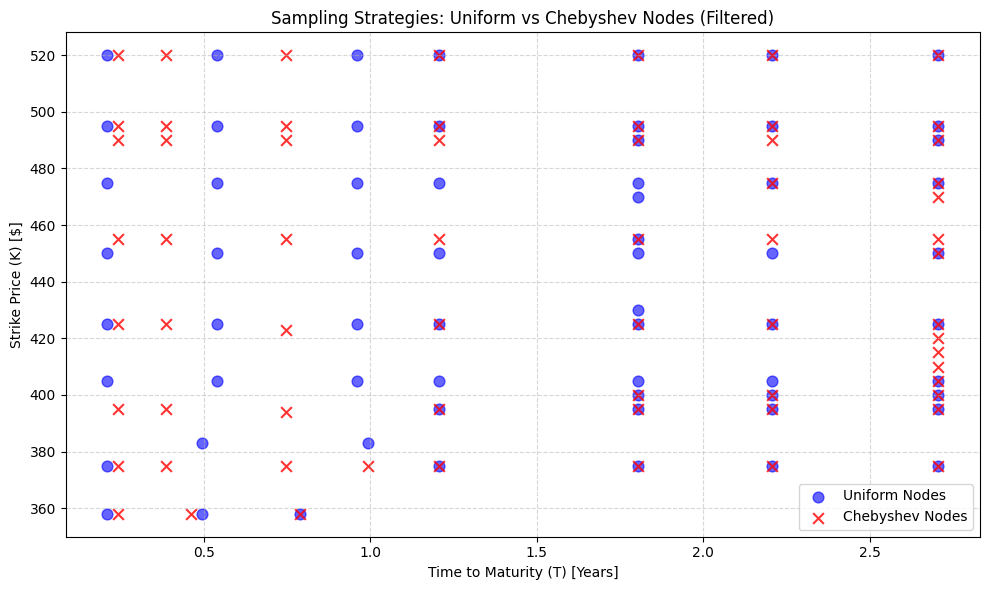

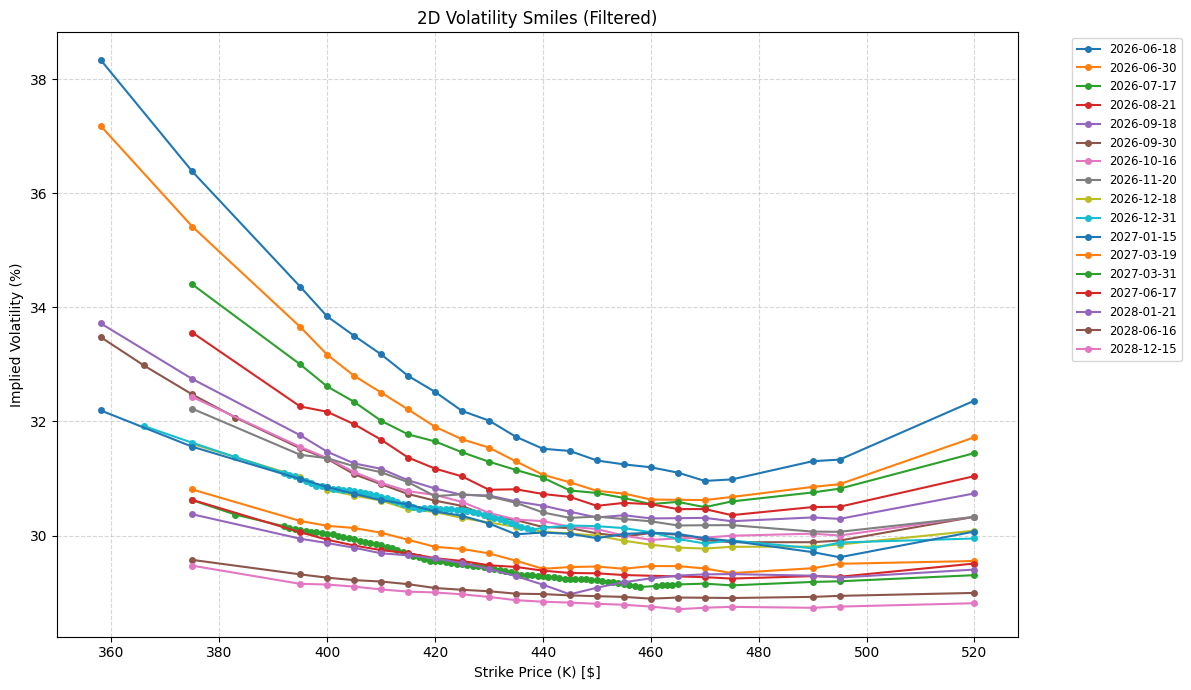

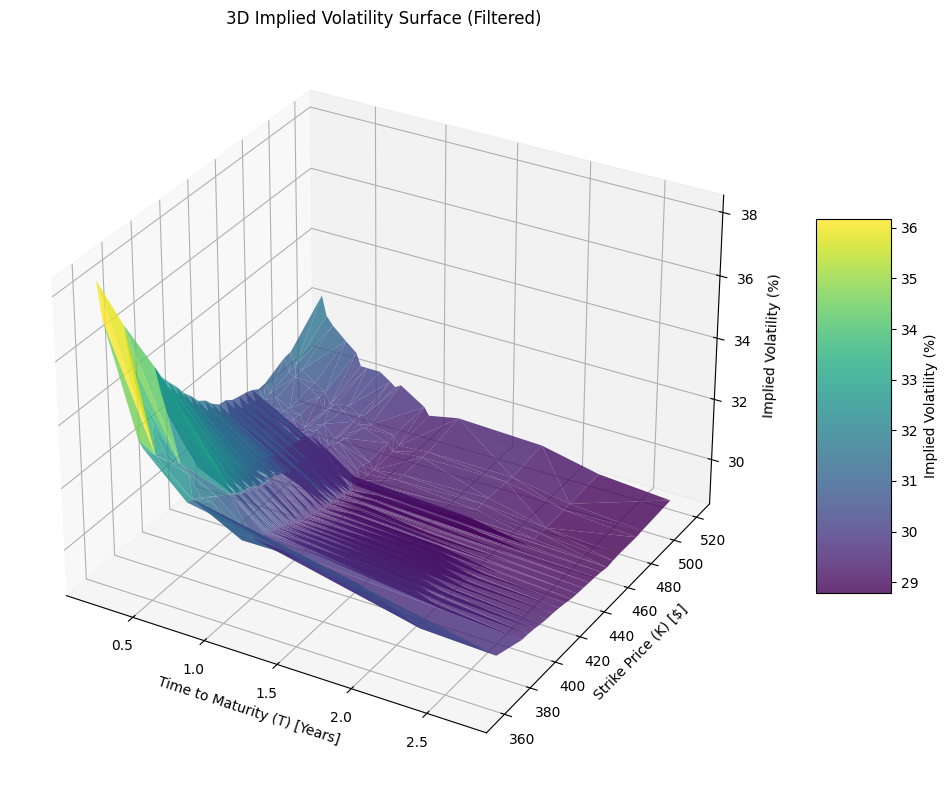

In [7]:
def plot_visualizations(df_all, df_uni, df_cheb):
    os.makedirs("Data", exist_ok=True)
    
    # 1. 2D Scatter Plot: Sampling Comparison
    plt.figure(figsize=(10, 6))
    plt.scatter(df_uni['T'], df_uni['K'], color='blue', label='Uniform Nodes', alpha=0.6, s=60, marker='o')
    plt.scatter(df_cheb['T'], df_cheb['K'], color='red', label='Chebyshev Nodes', alpha=0.8, s=60, marker='x')
    plt.title("Sampling Strategies: Uniform vs Chebyshev Nodes (Filtered)")
    plt.xlabel("Time to Maturity (T) [Years]")
    plt.ylabel("Strike Price (K) [$]")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("Data/sampling_comparison.png")
    plt.show()

    # 2. 2D Volatility Smiles
    plt.figure(figsize=(12, 7))
    for exp in sorted(df_all['expiry'].unique()):
        subset = df_all[df_all['expiry'] == exp].sort_values('K')
        plt.plot(subset['K'], subset['implied_vol'] * 100, marker='o', markersize=4, label=str(exp))
    plt.title("2D Volatility Smiles (Filtered)")
    plt.xlabel("Strike Price (K) [$]")
    plt.ylabel("Implied Volatility (%)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig("Data/volatility_smiles_2d.png")
    plt.show()

    # 3. 3D Volatility Surface
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_trisurf(df_all['T'], df_all['K'], df_all['implied_vol'] * 100, 
                           cmap='viridis', edgecolor='none', alpha=0.8)
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5, label="Implied Volatility (%)")
    ax.set_title("3D Implied Volatility Surface (Filtered)")
    ax.set_xlabel("Time to Maturity (T) [Years]")
    ax.set_ylabel("Strike Price (K) [$]")
    ax.set_zlabel("Implied Volatility (%)")
    plt.tight_layout()
    plt.savefig("Data/volatility_surface_3d.png")
    plt.show()

plot_visualizations(df_iv_all, dataset_uniform, dataset_chebyshev)

### **Sampling Error Evaluation**

In [8]:
print("\n[INFO] Volatility Surface Reconstruction Comparison...")
error_uniform = Sampling.evaluate_sampling_error(df_iv_all, dataset_uniform, "Uniform Grid")
error_chebyshev = Sampling.evaluate_sampling_error(df_iv_all, dataset_chebyshev, "Chebyshev Nodes")


[INFO] Volatility Surface Reconstruction Comparison...
--- Error Metrics: Uniform Grid ---
MAE (Mean Absolute Error) : 0.191%
RMSE (Root Mean Sq. Error)  : 0.252%
Max Error                   : 0.964%
---------------------------------------------
--- Error Metrics: Chebyshev Nodes ---
MAE (Mean Absolute Error) : 0.156%
RMSE (Root Mean Sq. Error)  : 0.223%
Max Error                   : 0.906%
---------------------------------------------


### **Error Heatmaps Visualization**

In [9]:
def plot_error_heatmaps(df_full, df_uni, df_cheb):
    """
    Generates side-by-side error heatmaps comparing Uniform and Chebyshev sampling.
    Shows where the interpolation errors are concentrated in the (T, K) space.
    """
    # 1. Normalize T and K for spatial interpolation
    T_min, T_max = df_full['T'].min(), df_full['T'].max()
    K_min, K_max = df_full['K'].min(), df_full['K'].max()
    
    T_full_norm = (df_full['T'] - T_min) / (T_max - T_min)
    K_full_norm = (df_full['K'] - K_min) / (K_max - K_min)
    IV_true = df_full['implied_vol'] * 100 # Evaluate in percentage
    
    # 2. Build RBF Interpolator for Uniform Grid
    T_uni_norm = (df_uni['T'] - T_min) / (T_max - T_min)
    K_uni_norm = (df_uni['K'] - K_min) / (K_max - K_min)
    rbf_uni = Rbf(T_uni_norm, K_uni_norm, df_uni['implied_vol'] * 100, function='thin_plate')
    
    IV_pred_uni = rbf_uni(T_full_norm, K_full_norm)
    error_uni = np.abs(IV_true - IV_pred_uni)
    
    # 3. Build RBF Interpolator for Chebyshev Nodes
    T_cheb_norm = (df_cheb['T'] - T_min) / (T_max - T_min)
    K_cheb_norm = (df_cheb['K'] - K_min) / (K_max - K_min)
    rbf_cheb = Rbf(T_cheb_norm, K_cheb_norm, df_cheb['implied_vol'] * 100, function='thin_plate')
    
    IV_pred_cheb = rbf_cheb(T_full_norm, K_full_norm)
    error_cheb = np.abs(IV_true - IV_pred_cheb)
    
    # 4. Plotting
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    # Define a common color scale boundary (vmin, vmax) for a fair visual comparison
    vmax = max(error_uni.max(), error_cheb.max())
    vmin = 0.0
    
    # Subplot 1: Uniform Error Heatmap
    cntr1 = axes[0].tricontourf(df_full['T'], df_full['K'], error_uni, 
                                levels=30, cmap='Reds', vmin=vmin, vmax=vmax)
    axes[0].scatter(df_uni['T'], df_uni['K'], color='black', marker='o', 
                    s=25, alpha=0.7, label='Uniform Nodes')
    axes[0].set_title('Interpolation Error: Uniform Grid (%)')
    axes[0].set_xlabel('Time to Maturity (T) [Years]')
    axes[0].set_ylabel('Strike Price (K) [$]')
    axes[0].legend(loc='upper right')
    
    # Subplot 2: Chebyshev Error Heatmap
    cntr2 = axes[1].tricontourf(df_full['T'], df_full['K'], error_cheb, 
                                levels=30, cmap='Reds', vmin=vmin, vmax=vmax)
    axes[1].scatter(df_cheb['T'], df_cheb['K'], color='black', marker='x', 
                    s=35, alpha=0.8, label='Chebyshev Nodes')
    axes[1].set_title('Interpolation Error: Chebyshev Nodes (%)')
    axes[1].set_xlabel('Time to Maturity (T) [Years]')
    axes[1].legend(loc='upper right')
    
    # Add a single colorbar for both subplots
    cbar = fig.colorbar(cntr1, ax=axes, shrink=0.9, location='right', pad=0.02)
    cbar.set_label('Absolute Error (|True - Predicted| %)')
    
    plt.suptitle("Volatility Surface Reconstruction Error: Uniform vs Chebyshev", fontsize=14, y=1.02)
    
    os.makedirs("Data", exist_ok=True)
    out_path = "Data/error_heatmaps_comparison.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"[INFO] Error heatmaps successfully generated and saved to {out_path}")
    plt.show()


[INFO] Generating Error Heatmaps...
[INFO] Error heatmaps successfully generated and saved to Data/error_heatmaps_comparison.png


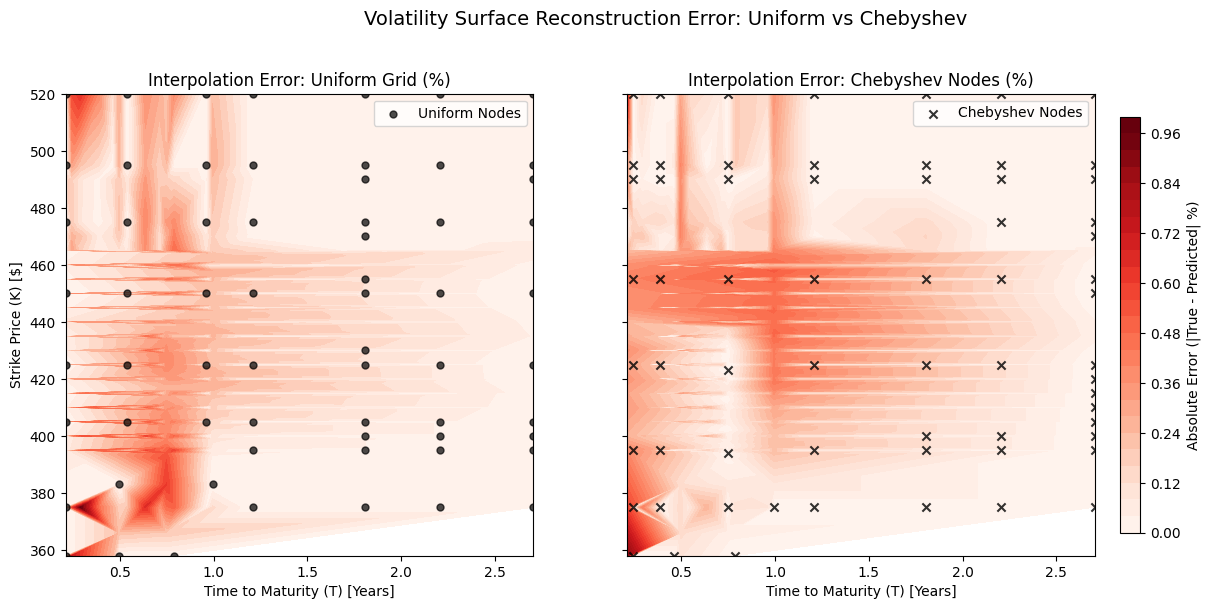

In [10]:
print("\n[INFO] Generating Error Heatmaps...")
plot_error_heatmaps(df_iv_all, dataset_uniform, dataset_chebyshev)